### [UMAP: The Fast, Powerful Technique Behind Modern Dimensionality Reduction](https://medium.com/@roshmitadey/1d12ed341c75)

**UMAP** is a non-linear dimensionality reduction algorithm based on advanced mathematical concepts from topology and manifold theory.

> *High-dimensional data lies on a lower-dimensional manifold.*

> *UMAP tries to capture its true structure in fewer dimensions — while keeping points that are close together in high-dimensional space also close in the reduced space.*

In [1]:
# Install UMAP:
!pip install -qq umap-learn

In [2]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [3]:
# ---------------------------------------------
# 1. Load and scale high-dimensional data
# ---------------------------------------------

digits = load_digits()
X = digits.data              # 64-dimensional pixel data
y = digits.target            # labels (0–9)

# UMAP works best with scaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# ---------------------------------------------
# 2. Apply UMAP (reduce to 2 dimensions)
# ---------------------------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

display(umap_model)

X_umap = umap_model.fit_transform(X_scaled)

UMAP(random_state=42)

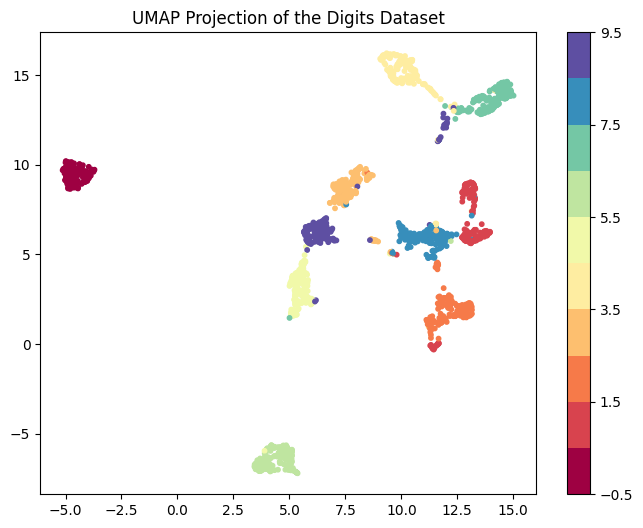

In [5]:
# ---------------------------------------------
# 3. Visualize UMAP embedding
# ---------------------------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=y,          # color by digit label
    s=10, cmap="Spectral"
)
plt.title("UMAP Projection of the Digits Dataset")
plt.colorbar(scatter, boundaries=np.arange(11)-0.5)
plt.show()

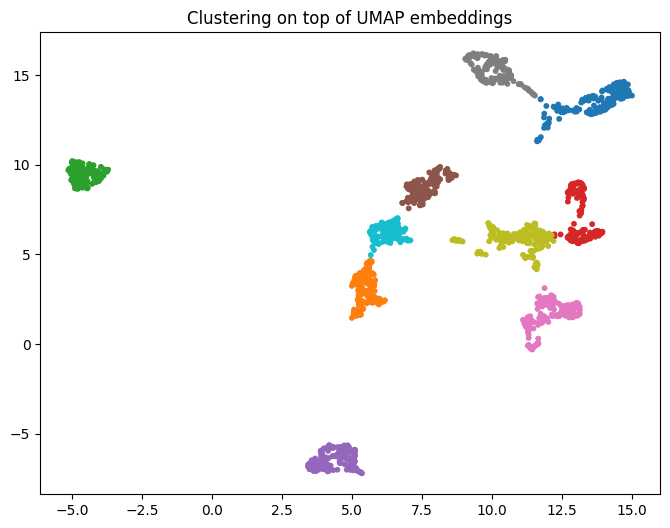

In [6]:
from sklearn.cluster import KMeans

# Apply KMeans on UMAP output
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_umap)
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap="tab10", s=10)
plt.title("Clustering on top of UMAP embeddings")
plt.show()